WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


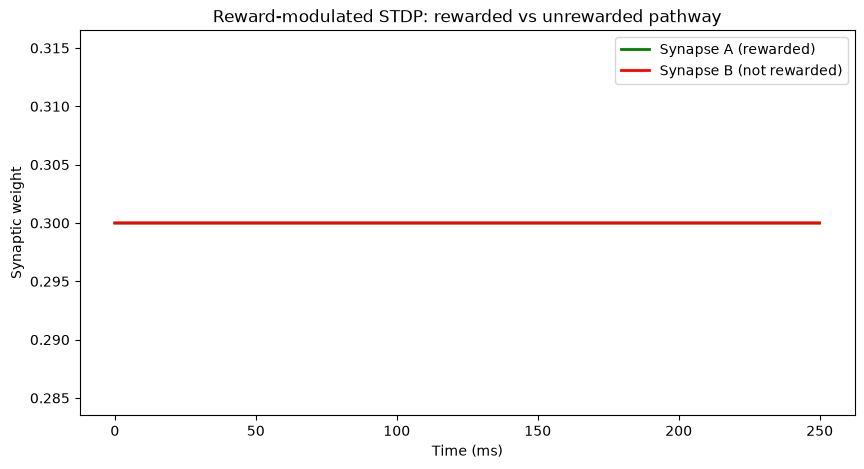

Final weight A (rewarded): 0.3000
Final weight B (not rewarded): 0.3000


In [3]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# Time constants
tau_mem = 10*ms
tau_pre = 20*ms
tau_post = 20*ms

# Output neuron
eqs = '''
dv/dt = -v/tau_mem : 1
'''
output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Two input neurons representing "pattern A" and "pattern B"
# Pattern A will be rewarded, pattern B will not
input_A = SpikeGeneratorGroup(1, [0]*5, [10, 60, 110, 160, 210]*ms)  # fires 5 times
input_B = SpikeGeneratorGroup(1, [0]*5, [35, 85, 135, 185, 235]*ms)  # fires 5 times, offset

# R-STDP synapse equations
# reward is a global variable we'll control manually between trials
stdp_eqs = '''
w : 1
dapre/dt = -apre/tau_pre : 1 (event-driven)
dapost/dt = -apost/tau_post : 1 (event-driven)
reward : 1 (shared)
'''

on_pre = '''
v_post += w
apre += 0.01
w = clip(w + apost * reward, 0, 1)
'''

on_post = '''
apost += 0.01
w = clip(w + apre * reward, 0, 1)
'''

S_A = Synapses(input_A, output, stdp_eqs, on_pre=on_pre, on_post=on_post)
S_A.connect()
S_A.w = 0.3
S_A.reward = 1.0  # Pattern A IS rewarded

S_B = Synapses(input_B, output, stdp_eqs, on_pre=on_pre, on_post=on_post)
S_B.connect()
S_B.w = 0.3
S_B.reward = 0.0  # Pattern B is NOT rewarded

weight_mon_A = StateMonitor(S_A, 'w', record=True)
weight_mon_B = StateMonitor(S_B, 'w', record=True)
spike_mon = SpikeMonitor(output)

run(250*ms)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weight_mon_A.t/ms, weight_mon_A.w[0], label='Synapse A (rewarded)', color='green', linewidth=2)
ax.plot(weight_mon_B.t/ms, weight_mon_B.w[0], label='Synapse B (not rewarded)', color='red', linewidth=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Synaptic weight')
ax.set_title('Reward-modulated STDP: rewarded vs unrewarded pathway')
ax.legend()
plt.show()

print(f"Final weight A (rewarded): {S_A.w[0]:.4f}")
print(f"Final weight B (not rewarded): {S_B.w[0]:.4f}")

In [4]:
print(f"Input A spike times: {input_A.spike_time if hasattr(input_A, 'spike_time') else 'check below'}")
print(f"Output spikes: {spike_mon.t}")
print(f"Number of output spikes: {len(spike_mon.t)}")

Input A spike times: <spikegeneratorgroup.spike_time: array([ 10.,  60., 110., 160., 210.]) * msecond>
Output spikes: <spikemonitor.t: array([], dtype=float64) * second>
Number of output spikes: 0


Output spikes: 10
Final weight A (rewarded): 0.9843
Final weight B (not rewarded): 0.9000


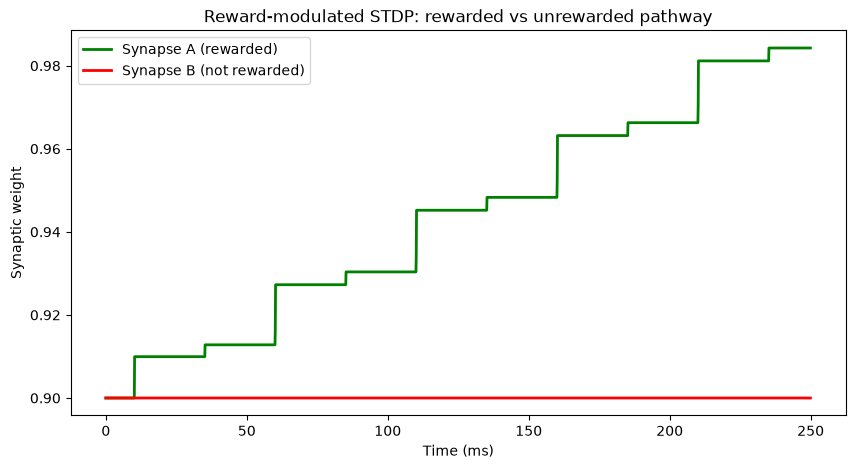

In [6]:
start_scope()

tau_mem = 10*ms
tau_pre = 20*ms
tau_post = 20*ms

eqs = '''
dv/dt = -v/tau_mem : 1
'''
output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

input_A = SpikeGeneratorGroup(1, [0]*5, [10, 60, 110, 160, 210]*ms)
input_B = SpikeGeneratorGroup(1, [0]*5, [35, 85, 135, 185, 235]*ms)

stdp_eqs = '''
w : 1
dapre/dt = -apre/tau_pre : 1 (event-driven)
dapost/dt = -apost/tau_post : 1 (event-driven)
reward : 1 (shared)
'''

on_pre = '''
v_post += w
apre += 0.01
w = clip(w + apost * reward, 0, 1)
'''

on_post = '''
apost += 0.01
w = clip(w + apre * reward, 0, 1)
'''

S_A = Synapses(input_A, output, stdp_eqs, on_pre=on_pre, on_post=on_post)
S_A.connect()
S_A.w = 0.9  # increased from 0.3 - single spike should now cross threshold
S_A.reward = 1.0

S_B = Synapses(input_B, output, stdp_eqs, on_pre=on_pre, on_post=on_post)
S_B.connect()
S_B.w = 0.9
S_B.reward = 0.0

weight_mon_A = StateMonitor(S_A, 'w', record=True)
weight_mon_B = StateMonitor(S_B, 'w', record=True)
spike_mon = SpikeMonitor(output)

run(250*ms)

print(f"Output spikes: {len(spike_mon.t)}")
print(f"Final weight A (rewarded): {S_A.w[0]:.4f}")
print(f"Final weight B (not rewarded): {S_B.w[0]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weight_mon_A.t/ms, weight_mon_A.w[0], label='Synapse A (rewarded)', color='green', linewidth=2)
ax.plot(weight_mon_B.t/ms, weight_mon_B.w[0], label='Synapse B (not rewarded)', color='red', linewidth=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Synaptic weight')
ax.set_title('Reward-modulated STDP: rewarded vs unrewarded pathway')
ax.legend()
plt.show()

Halfway - Weight A: 0.9843, Weight B: 0.9000
Reward flipped! A is now unrewarded, B is now rewarded.

Final - Weight A: 0.9843, Weight B: 0.9899
Total output spikes: 20


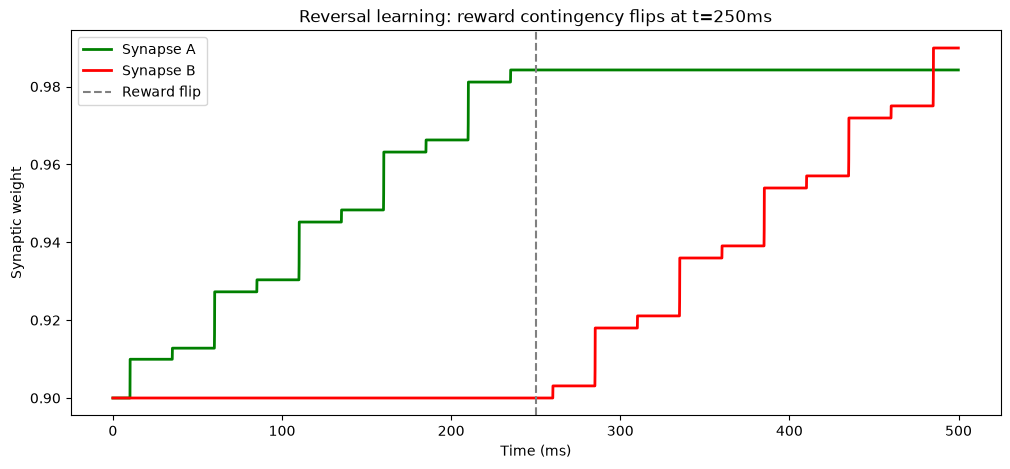

In [7]:
start_scope()

tau_mem = 10*ms
tau_pre = 20*ms
tau_post = 20*ms

eqs = '''
dv/dt = -v/tau_mem : 1
'''
output = NeuronGroup(1, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Extend the simulation - more spikes, spread over a longer time
# First half: A rewarded, B not. Second half: reward flips.
input_A_times = [10, 60, 110, 160, 210, 260, 310, 360, 410, 460]*ms
input_B_times = [35, 85, 135, 185, 235, 285, 335, 385, 435, 485]*ms

input_A = SpikeGeneratorGroup(1, [0]*10, input_A_times)
input_B = SpikeGeneratorGroup(1, [0]*10, input_B_times)

stdp_eqs = '''
w : 1
dapre/dt = -apre/tau_pre : 1 (event-driven)
dapost/dt = -apost/tau_post : 1 (event-driven)
reward : 1 (shared)
'''

on_pre = '''
v_post += w
apre += 0.01
w = clip(w + apost * reward, 0, 1)
'''

on_post = '''
apost += 0.01
w = clip(w + apre * reward, 0, 1)
'''

S_A = Synapses(input_A, output, stdp_eqs, on_pre=on_pre, on_post=on_post)
S_A.connect()
S_A.w = 0.9
S_A.reward = 1.0  # A rewarded initially

S_B = Synapses(input_B, output, stdp_eqs, on_pre=on_pre, on_post=on_post)
S_B.connect()
S_B.w = 0.9
S_B.reward = 0.0  # B not rewarded initially

weight_mon_A = StateMonitor(S_A, 'w', record=True)
weight_mon_B = StateMonitor(S_B, 'w', record=True)
spike_mon = SpikeMonitor(output)

# Run first half with original reward assignment
run(250*ms)

print(f"Halfway - Weight A: {S_A.w[0]:.4f}, Weight B: {S_B.w[0]:.4f}")

# FLIP THE REWARD
S_A.reward = 0.0  # A no longer rewarded
S_B.reward = 1.0  # B now rewarded!

print("Reward flipped! A is now unrewarded, B is now rewarded.")

# Run second half with flipped reward
run(250*ms)

print(f"\nFinal - Weight A: {S_A.w[0]:.4f}, Weight B: {S_B.w[0]:.4f}")
print(f"Total output spikes: {len(spike_mon.t)}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weight_mon_A.t/ms, weight_mon_A.w[0], label='Synapse A', color='green', linewidth=2)
ax.plot(weight_mon_B.t/ms, weight_mon_B.w[0], label='Synapse B', color='red', linewidth=2)
ax.axvline(x=250, color='gray', linestyle='--', label='Reward flip')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Synaptic weight')
ax.set_title('Reversal learning: reward contingency flips at t=250ms')
ax.legend()
plt.show()

## Reward-Modulated STDP — Observations & Results

### Motivation
Inspired by a paper reading session covering biologically plausible learning 
rules (Section 4.3, "Neuromorphic Computing 2025: Current SotA"), which 
described combining local learning rules with neuromodulatory reward signals 
to enable rapid adaptation in SNNs. This notebook implements a simplified, 
buildable version of this idea: reward-modulated STDP (R-STDP).

### Core mechanism
Standard STDP updates weights based purely on spike timing, regardless of 
outcome. R-STDP introduces a global `reward` signal that multiplies directly 
into the weight update:
w = clip(w + apost * reward, 0, 1)   # on post-synaptic spike
w = clip(w + apre * reward, 0, 1)    # on pre-synaptic spike

When `reward = 0`, the update is multiplied by zero regardless of the spike 
timing and hence no learning occurs even if the pathway is actively firing and 
contributing to behaviour. When `reward = 1`, the normal STDP proceeds.

### Architecture
- One output LIF neuron (threshold = 0.8)
- Two independent input pathways (A and B), each connected via R-STDP synapses
- Each pathway fires 5 (later 10) times at staggered intervals
- `reward` is a `(shared)` synapse variable, manually set per pathway

**Debugging note:** weight = 0.3 produced no learning at all
The initial attempt used `S.w = 0.3`, which never crossed the output neuron's 
threshold (0.8) on a single spike. With no output spikes, `on_post` never 
triggered, so `apost` never accumulated, and neither synapse could learn — 
mirroring the same "no post-synaptic activity, no STDP" finding from the 
Lava STDP investigation (notebook 08), now reproduced independently in Brian2.

**Fix:** increased weight to 0.9, allowing a single input spike to cross 
threshold and reliably trigger output spikes.

### Key finding 1: differential learning under fixed reward
With pathway A rewarded (`reward=1.0`) and pathway B unrewarded 
(`reward=0.0`) throughout:

| Synapse | Final weight | Behaviour |
|---------|--------------|-----------|
| A (rewarded) | 0.9843 | Staircase increase — where each spike pair produces a discrete weight step |
| B (not rewarded) | 0.9000 | Completely flat — despite firing and contributing to output spikes |

Both pathways were equally *active* (both caused output spikes), but only 
the rewarded pathway *adapted*. This cleanly demonstrates that activity 
alone is not sufficient for learning in this model — reward determines 
whether activity translates into lasting synaptic change.

### Key finding 2: reversal learning — the dynamic reward reassignment
Extended the simulation to 500ms and flipped the reward assignment at the 
midpoint (t=250ms): A switched from rewarded → unrewarded, B switched from 
unrewarded → rewarded.

| Phase | Synapse A | Synapse B |
|-------|-----------|-----------|
| t=0 (start) | 0.9000 | 0.9000 |
| t=250ms (flip point) | 0.9843 | 0.9000 |
| t=500ms (end) | 0.9843 (frozen) | 0.9899 (now climbing) |

Synapse A's weight immediately froze after the reward flip, despite 
continuing to fire — confirming the network stopped reinforcing a pathway 
the instant it stopped being rewarded, with no lag or unlearning needed. 
Synapse B began climbing immediately once rewarded, picking up its own 
staircase pattern.

### Significance
This is a working, minimal model of **credit assignment** — the problem of 
determining which of several active pathways deserves reinforcement based 
on outcome, a foundational concept in both neuroscience and reinforcement 
learning. The reversal learning result specifically demonstrates real-time 
adaptation to a changing reward contingency, directly relevant to the 
paper's description of "one-shot or few-shot learning for tasks like 
navigation and adaptation."

### Relationship to e-prop (noted for future work)
This R-STDP implementation is a simplified instance of neuromodulated local 
learning. The paper's discussion of **e-prop** (Bellec et al., 2020) 
describes a more general and scalable framework using eligibility traces 
for training full recurrent SNNs — a natural, more advanced extension of 
the ideas explored here. Planned as a future multi-session project.